Importing Libraries



In [115]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
sns.set_style("whitegrid")

Since the dataset is uploaded on a website, we can acess by kagglehub or by directly uploading the dataset

In [117]:
#via kagglehub

import kagglehub

# Download latest version
path = kagglehub.dataset_download("himanshupoddar/zomato-bangalore-restaurants")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'zomato-bangalore-restaurants' dataset.
Path to dataset files: /kaggle/input/zomato-bangalore-restaurants


In [118]:
#directly uploading to google colab
#code is commented out


# from google.colab import files
# import pandas as pd
# import io

# uploaded = files.upload()

# file_name = list(uploaded.keys())[0]

# df = pd.read_csv(io.BytesIO(uploaded[file_name]))
# print(df.head())


Loading Dataset

In [119]:
df = pd.read_csv('/kaggle/input/zomato-bangalore-restaurants/zomato.csv').copy()
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


**DATA EXPLORATION + CLEANING**

Dataset Inspection

In [120]:
#shape
print(df.shape)
print("\n")
#Columns
print(df.columns)
print("\n")
#Data Types
print(df.dtypes)
print("\n")
#Missing Values
print(df.isnull().sum())
print("\n")
#Remove Duplicates
df.drop_duplicates(inplace = True)
#Handle Missing Values
df = df.dropna(subset=['rate', 'approx_cost(for two people)'])

(51717, 17)


Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')


url                            object
address                        object
name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
phone                          object
location                       object
rest_type                      object
dish_liked                     object
cuisines                       object
approx_cost(for two people)    object
reviews_list                   object
menu_item                      object
listed_in(type)                object
listed_in(city)                object
dtype: object


url                                0
add

**Data Cleaning**

In [121]:
#Clean Rate Column
df['rate'] = df['rate'].astype(str)
df['rate'] = df['rate'].str.replace('/5', '', regex=False)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

#Clean cost column
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'], errors='coerce'
)

print(df[['rate', 'approx_cost(for two people)']].head())

   rate  approx_cost(for two people)
0   4.1                        800.0
1   4.1                        800.0
2   3.8                        800.0
3   3.7                        300.0
4   3.8                        600.0


**FEATURE ENGINEERING**

In [122]:
#cost per person
df['cost_per_person'] = df['approx_cost(for two people)']/2

#Rating category
def rating_category(x):
    if x < 3.5:
        return 'Low'
    elif x <= 4.2:
        return 'Medium'
    else:
        return 'High'

df['rating_category'] = df['rate'].apply(rating_category)

print(df[['cost_per_person', 'rating_category']].head())

   cost_per_person rating_category
0            400.0          Medium
1            400.0          Medium
2            400.0          Medium
3            150.0          Medium
4            300.0          Medium


**CATEGORICAL ANALYSIS**

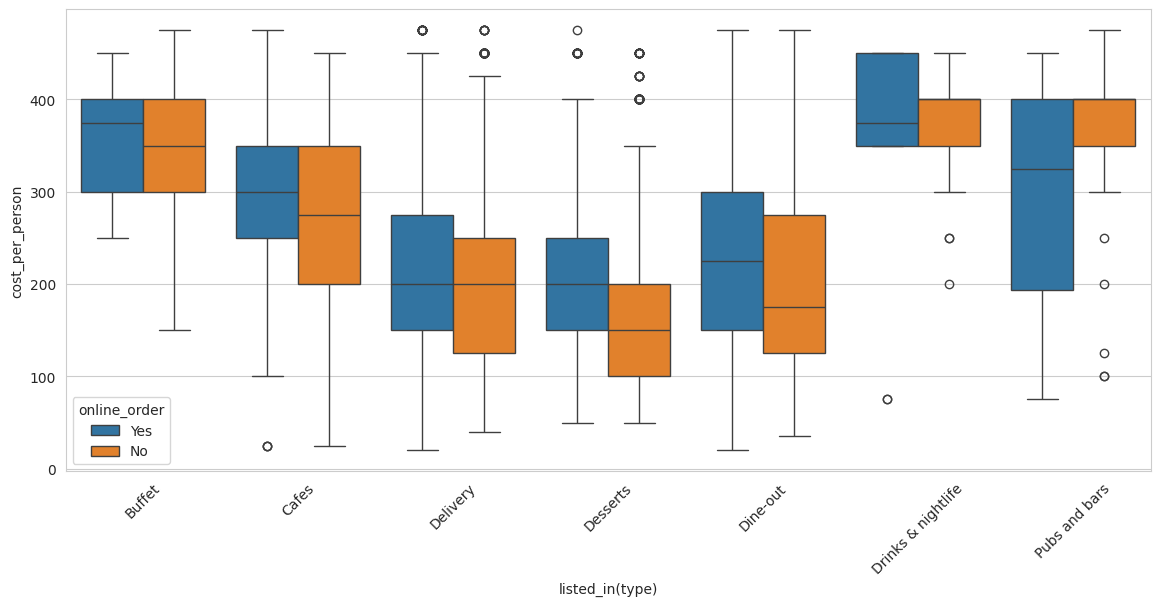

In [123]:
#Boxplot Analysis
plt.figure(figsize=(14, 6))
sns.boxplot(
    x='listed_in(type)',
    y = 'cost_per_person',
     hue='online_order',
    data=df
)

plt.xticks(rotation=45)
plt.show()

**Interquartile Range**

In [124]:
#Outlier Detection
Q1 = df['cost_per_person'].quantile(0.25)
Q3 = df['cost_per_person'].quantile(0.50)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[
    (df['cost_per_person'] < lower) |
    (df['cost_per_person'] > upper)
]

print(outliers[['name', 'cost_per_person']].head())

              name  cost_per_person
0            Jalsa            400.0
1   Spice Elephant            400.0
2  San Churro Cafe            400.0
4    Grand Village            300.0
5  Timepass Dinner            300.0


IQR method detects extreme values.

Luxury restaurants become outliers

**VIOLIN PLOT INSIGHT**

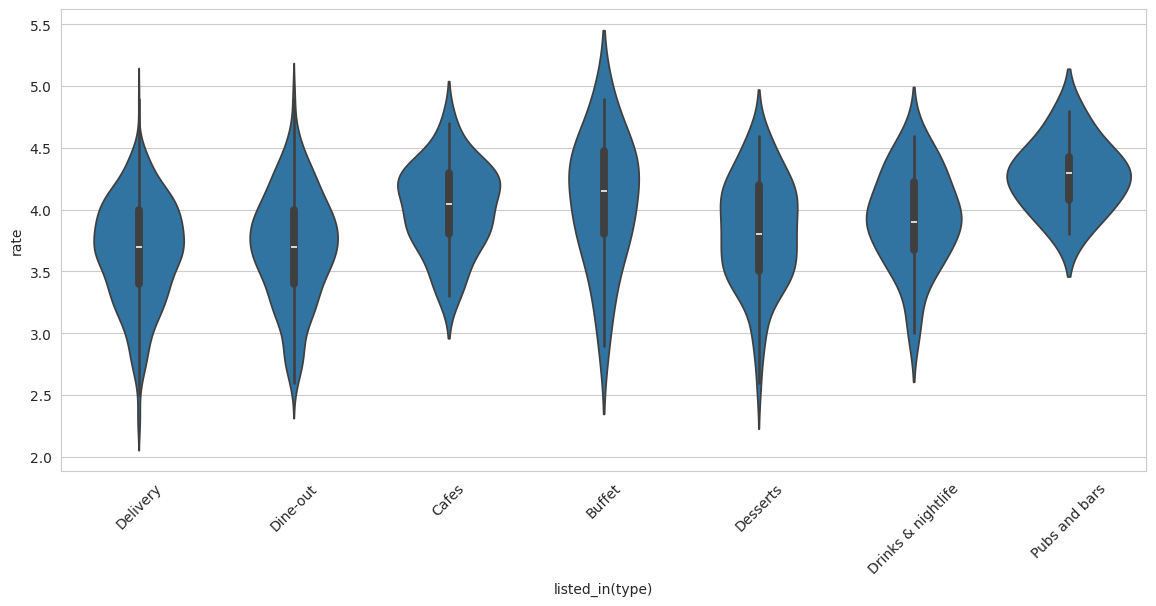

In [125]:
sample_df = df.sample(1000)
plt.figure(figsize=(14, 6))

sns.violinplot(
    x = 'listed_in(type)',
    y = 'rate',
    data=sample_df
)

plt.xticks(rotation=45)
plt.show()

IQR method detects extreme values.

Luxury restaurannts become outliers.

**VIOLIN PLOT INSIGHT**

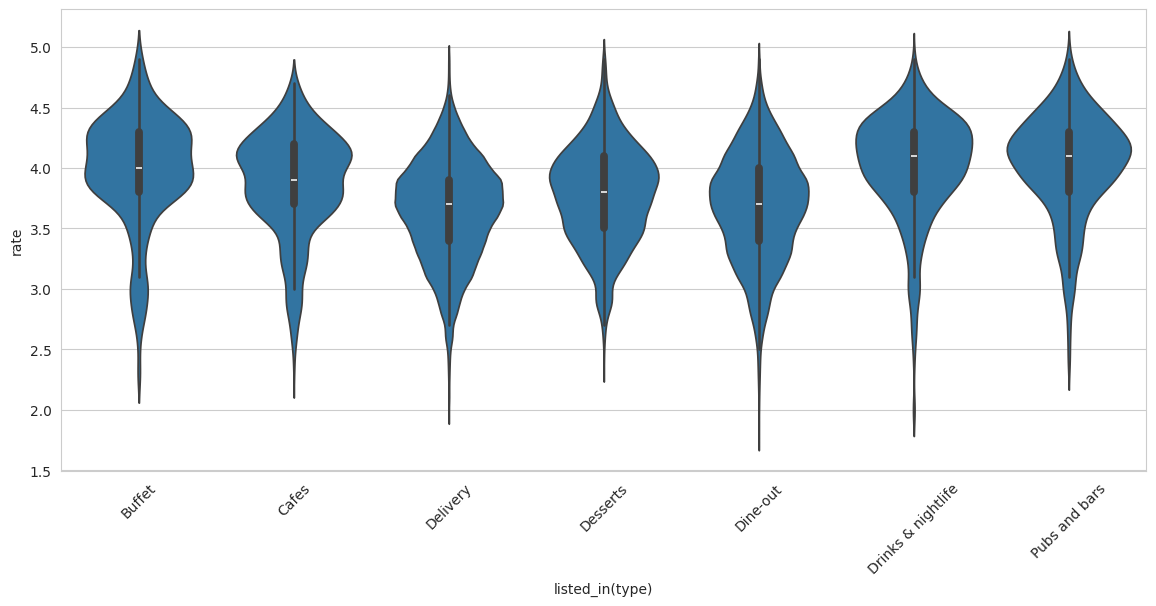

In [126]:
plt.figure(figsize=(14, 6))

sns.violinplot(
    x = 'listed_in(type)',
    y = 'rate',
    data =  df
)

plt.xticks(rotation = 45)
plt.show()

Categories with multiple peaks show multi-modal behaviour.

Cafes and Buffets often multiple rating groups.

**SWARMPLOT DENSITY**

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 42.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 14.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 46.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 21.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


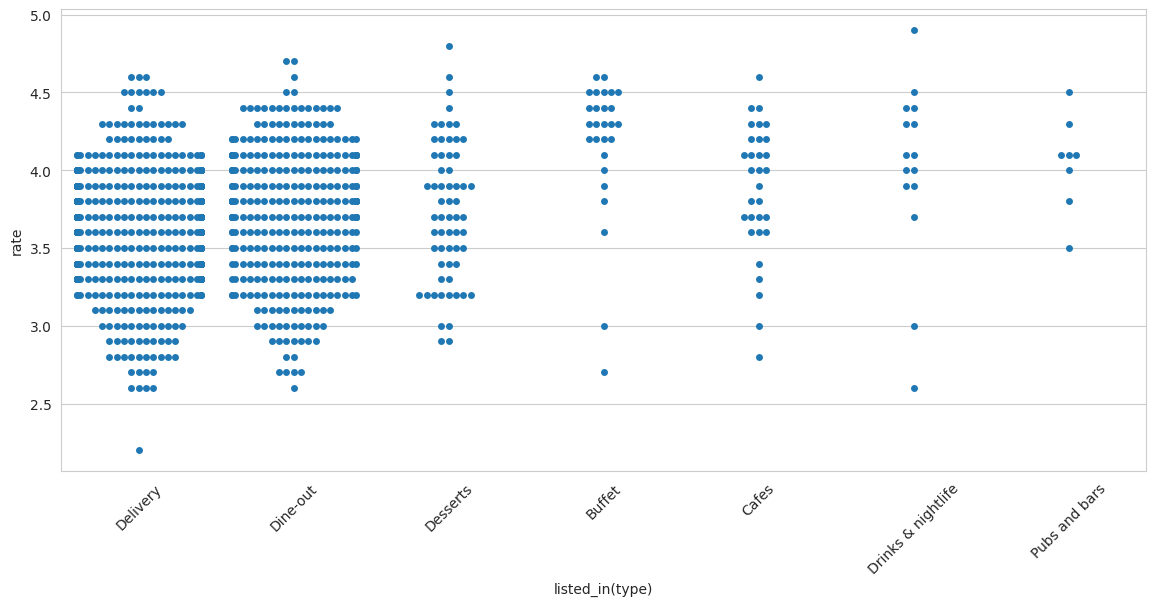

In [127]:
sample_df = df.sample(1000)

plt.figure(figsize=(14,6))

sns.swarmplot(
    x='listed_in(type)',
    y='rate',
    data=sample_df
)

plt.xticks(rotation=45)
plt.show()

Cafes and Fine Dining usually have dense high ratings.

**BUSINESS ANALYSIS**

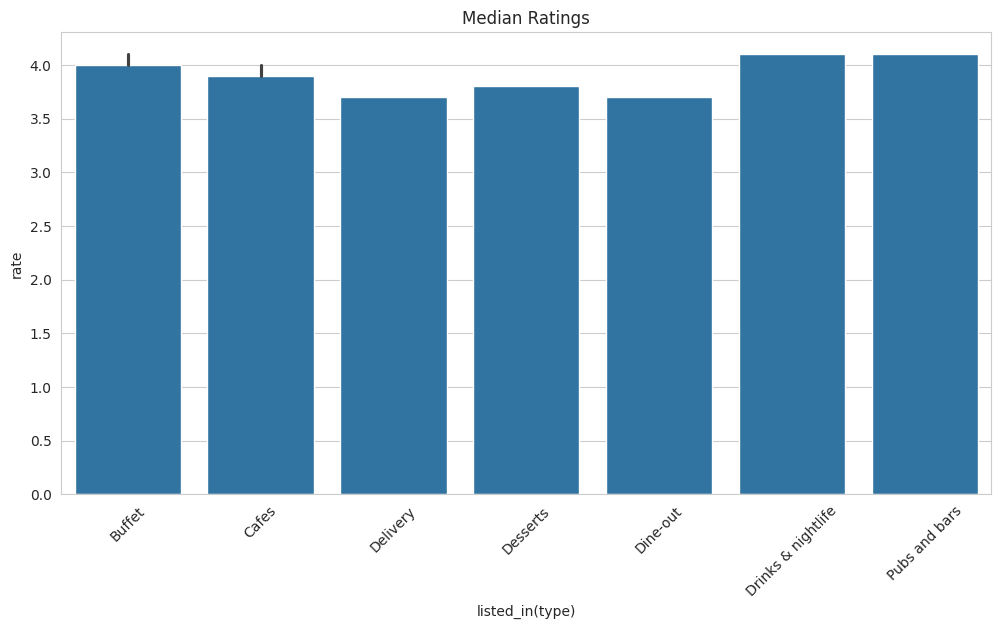

In [128]:
#Median
plt.figure(figsize=(12, 6))

sns.barplot(
    x = 'listed_in(type)',
    y = 'rate',
    data = df,
    estimator = np.median
)

plt.xticks(rotation=45)
plt.title('Median Ratings')
plt.show()

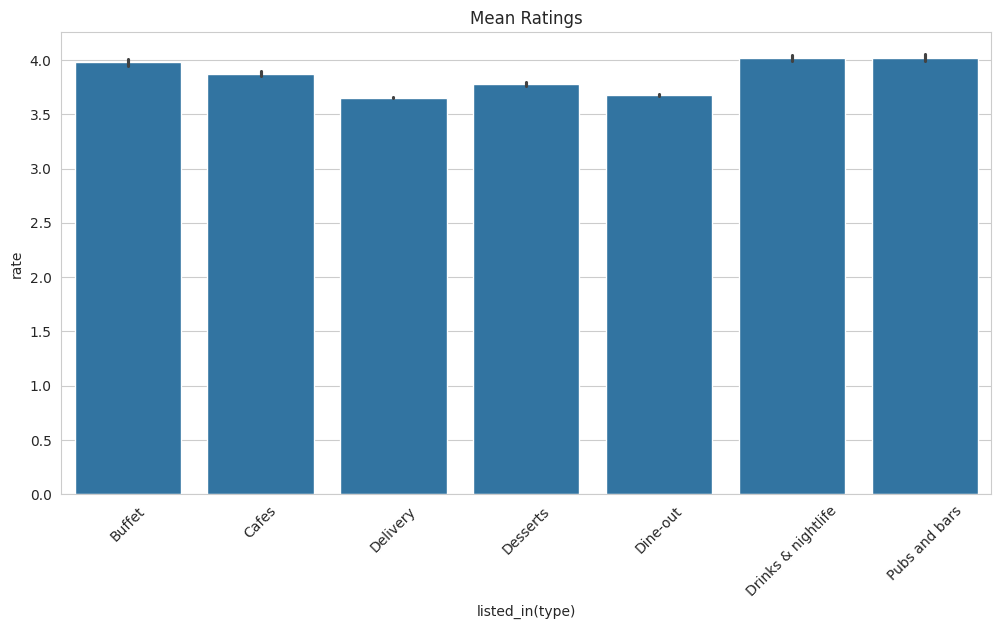

In [129]:
#Mean
plt.figure(figsize=(12, 6))

sns.barplot(
    x = 'listed_in(type)',
    y = 'rate',
    data = df,
    estimator = np.mean
)

plt.xticks(rotation=45)
plt.title('Mean Ratings')
plt.show()

Mean is affected by outliers.

Median gives moves stable central tendecy

**COUNTPLOT**

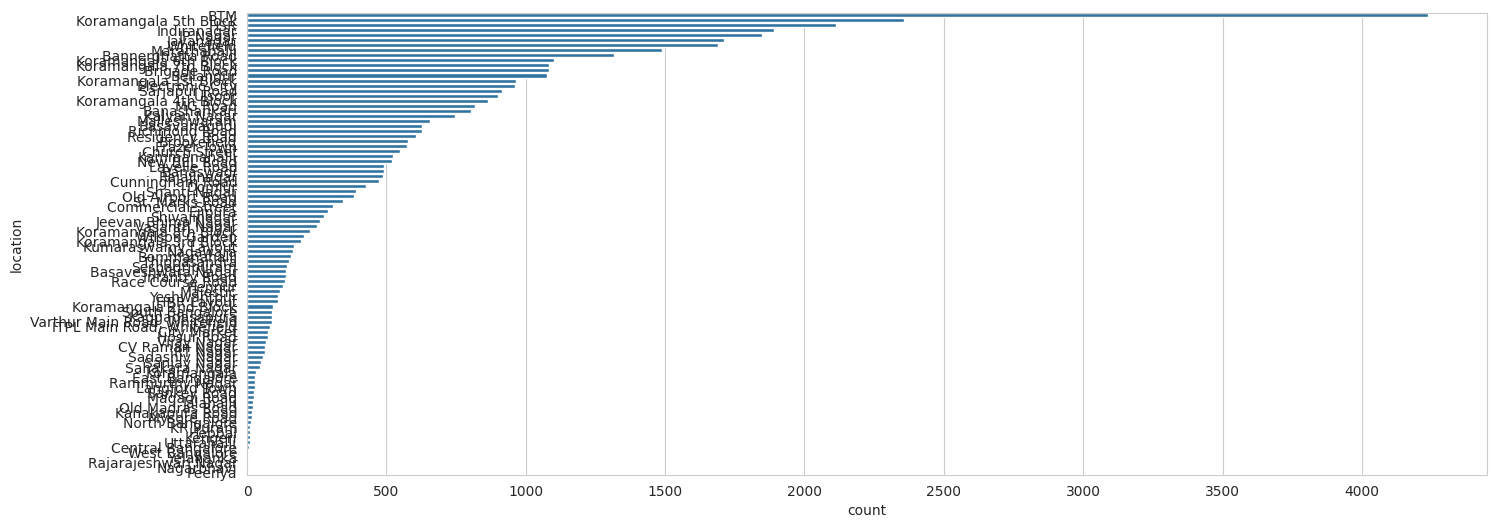

In [130]:
plt.figure(figsize=(16, 6))

sns.countplot(
    y = 'location',
    data = df,
    order=df['location'].value_counts().index
)

plt.show()

Areas like BTM, Koramangala, and Whitefield usually have highest restaurant concentration

**REVENUE INSIGHT**

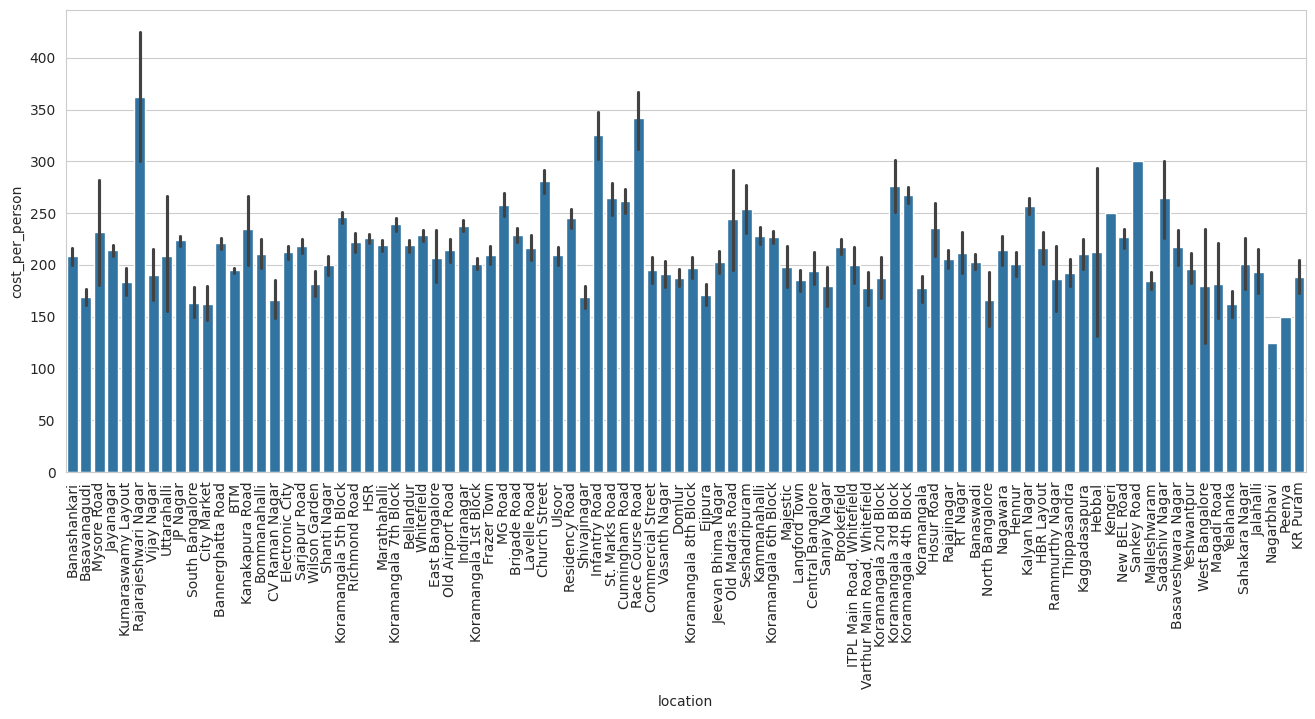

In [131]:
plt.figure(figsize=(16, 6))

sns.barplot(
    x = 'location',
    y = 'cost_per_person',
    data = df,
    estimator =np.mean
)

plt.xticks(rotation=90)
plt.show()

Premium areas generally show higher average pricing.

**INTERACTION EFFECTS**

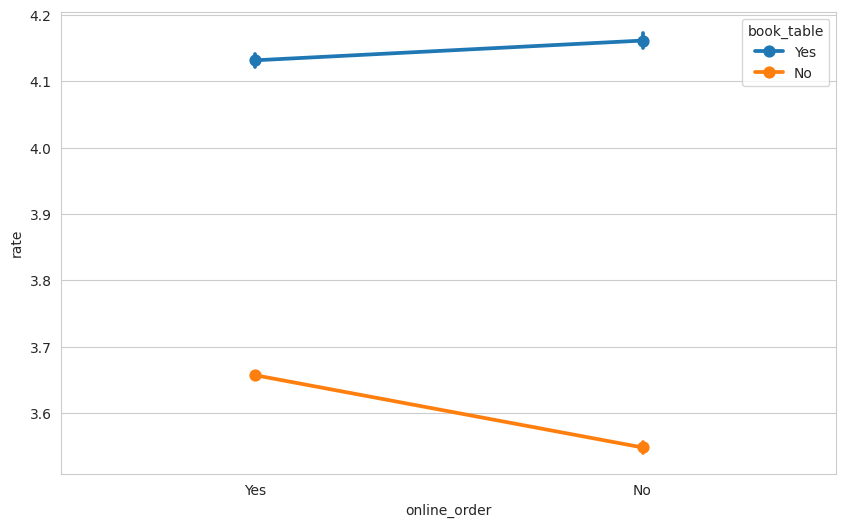

In [132]:
#Pointplot Interaction

plt.figure(figsize=(10,6))

sns.pointplot(
    x='online_order',
    y='rate',
    hue='book_table',
    data=df
)

plt.show()

Restaurants with both booking and online ordering often have slightly higher ratings.

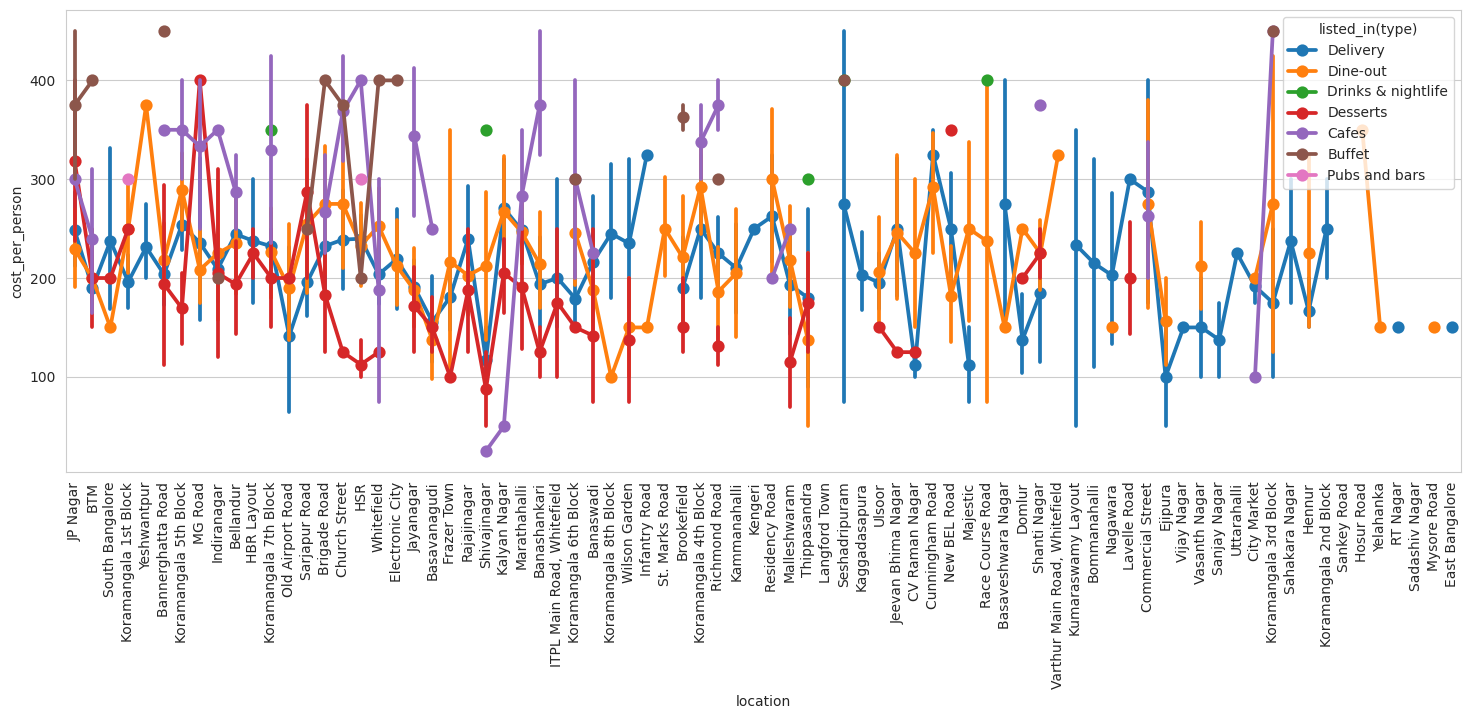

In [133]:
sample_df = df.sample(2000)

plt.figure(figsize=(18,6))

sns.pointplot(
    x = 'location',
    y = 'cost_per_person',
    hue = 'listed_in(type)',
    data=sample_df
)

plt.xticks(rotation=90)
plt.show()

Restaurants category impacts pricing differently across locations

**DISTRIBUTION ANALYSIS**

Histogram Tuning

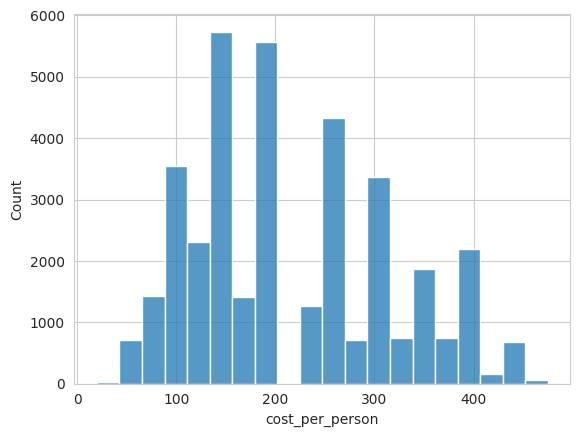

In [134]:
#bins =  20
sns.histplot(df['cost_per_person'], bins=20)
plt.show()

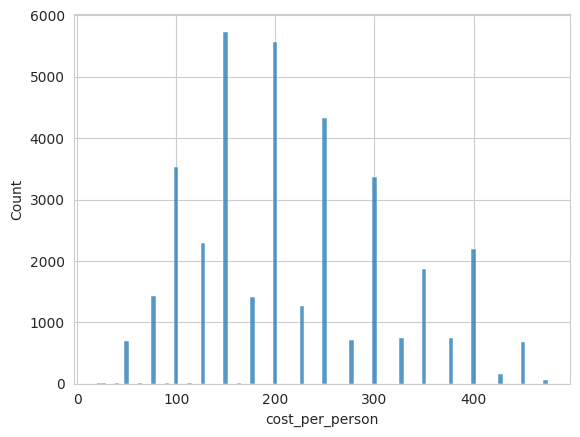

In [135]:
#bins = 100
sns.histplot(df['cost_per_person'], bins=100)
plt.show()

100 bins shows pricing clusters more clearly.

20 bins gives smoother distribution.

**KDE Analysis**

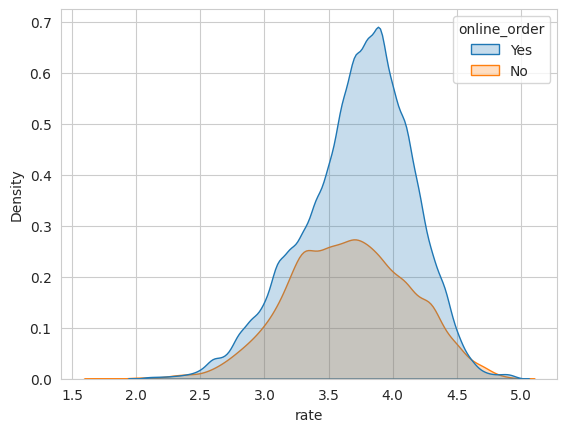

In [136]:
sns.kdeplot(
    data = df,
    x = 'rate',
    hue = 'online_order',
    fill = True
)

plt.show()

Online-order restaurants usually show higher rating density.

**SKEWNESS DETECTION**

0.47842899466326055


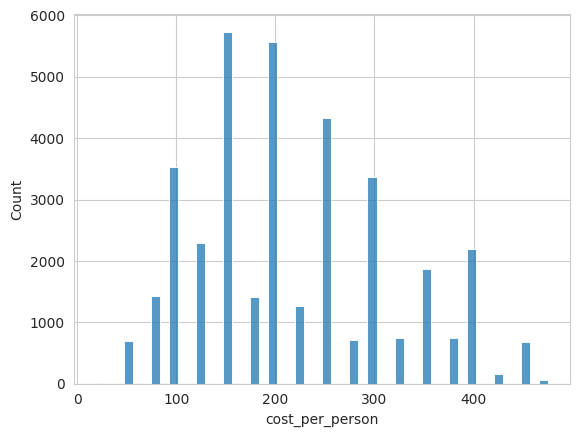

In [137]:
print(df['cost_per_person'].skew())

sns.histplot(df['cost_per_person'], bins=50)
plt.show()

Positive skewness indicates many affordable restaurants with few expensive ones.

**ECDF ANALYSIS**

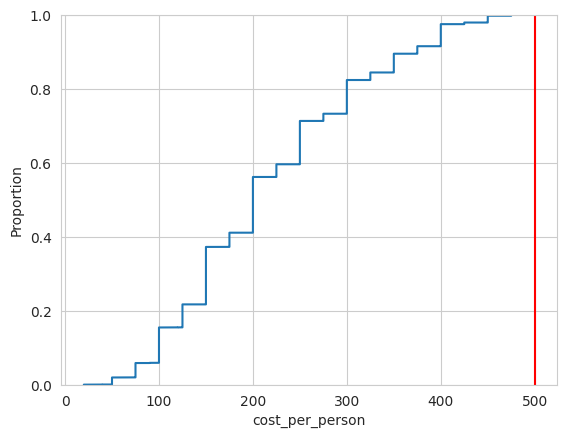

In [138]:
sns.ecdfplot(data=df, x='cost_per_person')
plt.axvline(500, color='red')
plt.show()

In [139]:
#percentage calculation
percentage = (
    (df['cost_per_person'] < 500).mean()
) * 100
print(percentage)

84.44037537193866


Large percentage of restaurants cost  below ₹500/person.

**PROBABILITY QUESTION**

In [140]:
probability = (
    (df['cost_per_person'] > 1000).mean()
)
print(probability)

0.0


Very small percentage belong to premium luxury pricing.

**MULTIVARIATE ANALYSIS**

2D Histogram

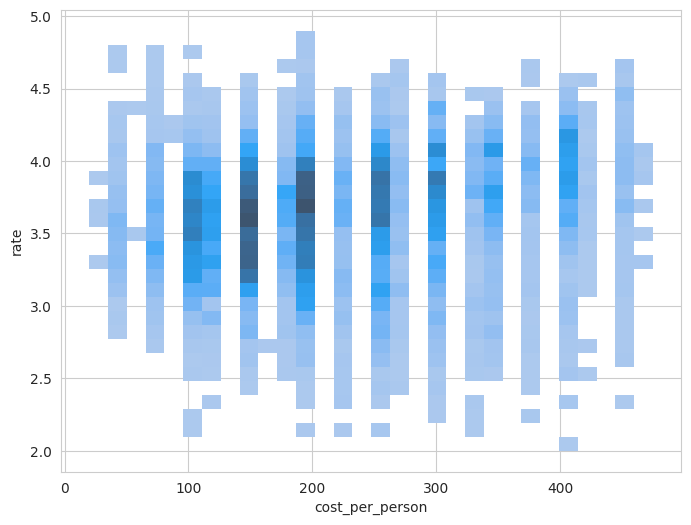

In [141]:
plt.figure(figsize=(8, 6))

sns.histplot(data=df,
             x = 'cost_per_person',
             y='rate',
             bins=30
             )
plt.show()

Moderate positive relationship between pricing and ratings.

**KDE Contour Plot**

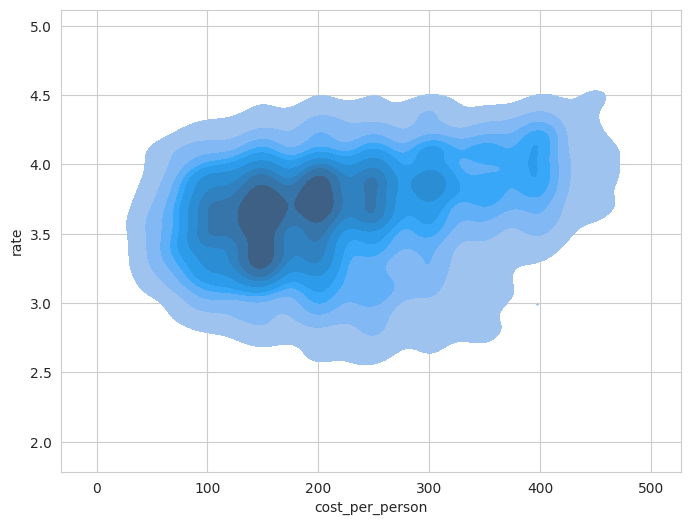

In [142]:
plt.figure(figsize=(8, 6))

sns.kdeplot(
    data=df,
    x='cost_per_person',
    y = 'rate',
    fill=True
)

plt.show()

HIghest density cluster usually lies in medium-high rating range.

**ADVANCED FACETING**

Catplot

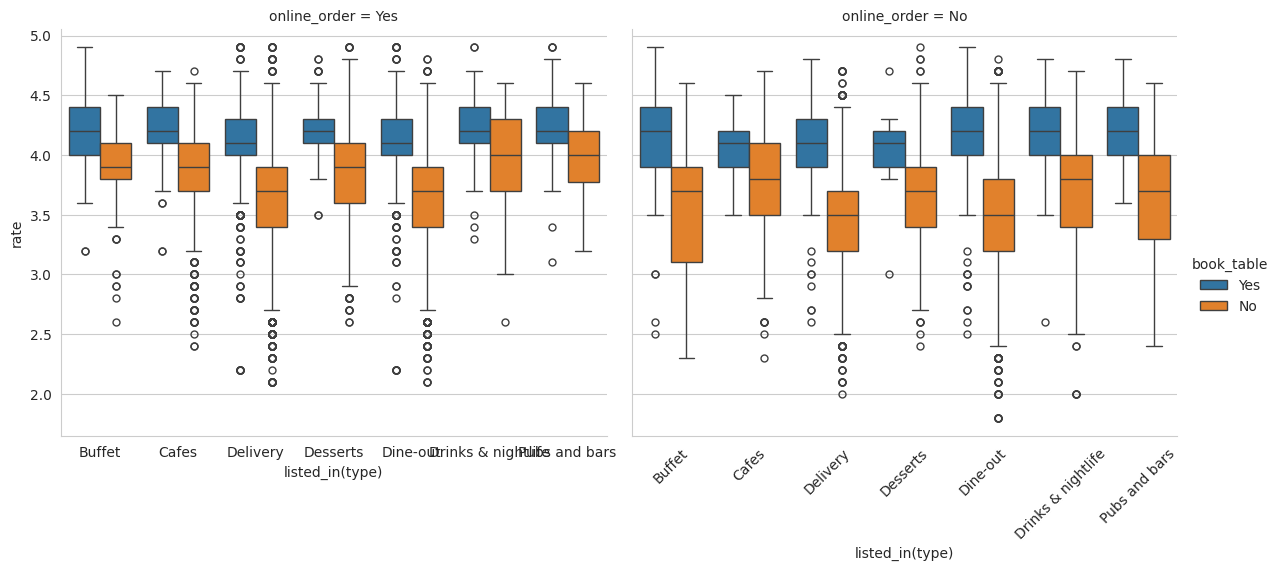

In [143]:
sns.catplot(
    kind='box',
    x='listed_in(type)',
    y='rate',
    col='online_order',
    hue='book_table',
    data=df,
    height=5,
    aspect=1.2
)

plt.xticks(rotation=45)
plt.show()

Online ordering and table booking together often improve customer experience and ratings

**BUSINESS PROBLEM SOLUTION**

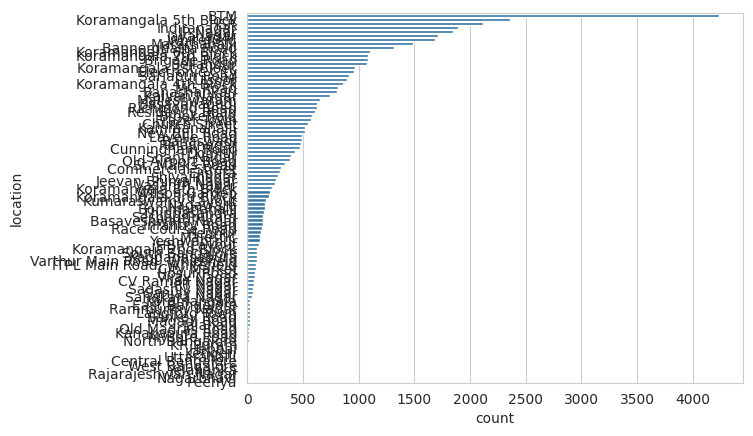

In [144]:
#Countplot of Locations
sns.countplot(
    y='location',
    data=df,
    order=df['location'].value_counts().index
)
plt.show()

The Best Locations

*   Koramangalam
*   BTM
*   Whitefield






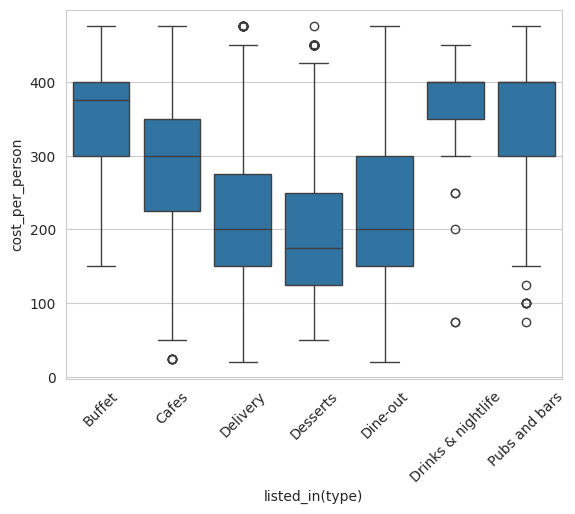

In [145]:
#Boxplot of Pricing
sns.boxplot(
    x='listed_in(type)',
    y='cost_per_person',
    data=df
)

plt.xticks(rotation=45)
plt.show()

Pricing Strategy:

*   Mid-range pricing performs best.
*   Extremely expensive restaurants are fewer



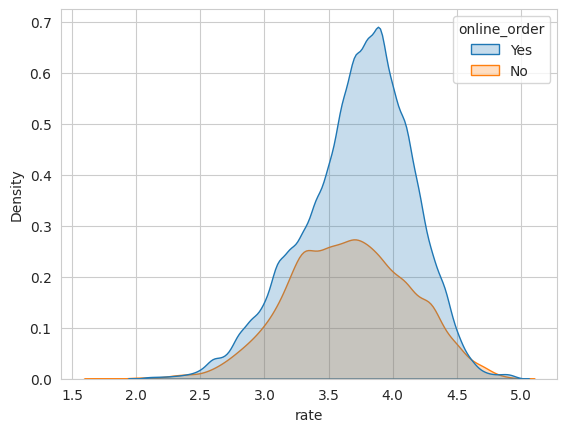

In [149]:
#KDE of Ratings
sns.kdeplot(data=df,
            x='rate', hue='online_order',
            fill=True)

plt.show()


Restaurant Types to Promote:
*   Cafes
*   Casual Dining
*   Quick Bites






Final Business Conclusion

*   Expand in high-demand areas.
*   Focus on affordable-to-mid pricing.
*   Promote online delivery-friendly restaurants.






In [ ]:
#Developing EDA pipeline

def analyze_restaurants(df):

    #CLEANING

    df = df.drop_duplicates()

    df = df.dropna(
        subset=['rate', 'approx_cost(for two people)']
    )

    df['rate'] = (
        df['rate']
        .astype(str)
        .str.replace("/5", regex=False)
    )

    df['rate'] = pd.to_numeric(
        df['rate'],
        errors='coerce'
    )
    df['approx_cost(for two people)'] = (
        df['approx_cost(for two people)'],
        errors='coerce'
    )

    #FEATURE ENGINEERING

    df['cost_per_person'] = (
        df['approx_cost(for two people)'] / 2
    )

    #VISUALISATIONS

    #1.Histogram
    sns.histoplot(df['cost_per_person'], bins=50)
    plt.title('Cost Distribution')
    plt.show()

    #2.Boxplot
    sns.boxplot(
        x = 'listed_in(type)',
        y = 'cost_per_person',
        data = df
    )

    plt.xticks(rotation = 45)
    plt.show()

    #3.KDE
    sns.kdeplot(
        data = df,
        x='rate',
        fill=True
    )
    plt.show()


    #4.Countplot
    sns.countplot(
        y='location',
        daata=df,
        order==df['location'].value_counts().index[:10]
    )
    plt.show()

    #5.Scatterplot
    sns.scatterplot(
        x='cost_per_person',
        y='rate',
        data=df
    )
    plt.show()

    #INSIGHTS

    print('Most restaurants are affordable.')
    print('Premium restaurants are fewer.')
    print('Higher ratings are concentrated around mdium pricing.')


**FINAL INSIGHT SUMMARY**

*   Bangalore restaurant market is highly competitive.
*   Bangalore restaurant market is highly competitive.
*  Online ordering positively affects ratings.
*  Premium restaurants exist mainly in high-end areas.
* Cafes and casual dining are strongest business categories.


